# 06b — RAG retrieval and Green audit

**Notebook version: 06b-rag-audit-v1**

本 Notebook 在任何 LLM/API 调用之前审计 05–06 的检索逻辑。它只运行本地 TF-IDF，不需要 API Key，也不会产生 token 费用。

核心问题：

1. 时间过滤和当前 division 排除是否持续有效；
2. 固定的 `2 manifesto + 4 historical + 1 bill + 1 fill` 是否硬塞入弱相关资料；
3. 不设来源配额的 Global Top‑8 会返回什么；
4. Green 的检索相关性是否系统性低于其他三个政党；
5. 哪些 query/evidence 需要进一步人工复核；
6. 是否有必要在下一版比较 dense 或 hybrid retrieval。

本步骤只评价检索结构和相似度，不能单独证明证据的政治含义正确。人工相关性复核仍是必要步骤。

## 1. Imports and configuration

In [1]:
# 导入本地检索、审计、统计与绘图需要的库。
from pathlib import Path
import importlib.util
import re
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.sparse import load_npz

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 180)

AUDIT_VERSION = '06b-rag-audit-v1'
RANDOM_STATE = 42
PARTIES = ['conservative', 'green', 'labour', 'liberal-democrat']
TARGET_DIVISIONS = 24
PER_DOMAIN_TARGET = 2
TOP_K = 8
ZERO_SCORE_TOLERANCE = 1e-12

ROOT = Path.cwd()
MODEL_DIR = ROOT / 'processed' / 'model_v2'
RAG_DIR = ROOT / 'processed' / 'rag_v1'
OUTPUT_DIR = ROOT / 'processed' / 'rag_audit_v1'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CHUNKS_PATH = RAG_DIR / 'rag_chunks.csv'
SPARSE_MATRIX_PATH = RAG_DIR / 'sparse_tfidf_matrix.npz'
VECTORIZER_PATH = RAG_DIR / 'sparse_tfidf_vectorizer.joblib'
VALIDATION_PATH = MODEL_DIR / 'model_validation_v2.csv'

# 06b 不安装或下载 dense 模型，只记录当前环境是否已经具备依赖。
DENSE_LIBRARY_AVAILABLE = (
    importlib.util.find_spec('sentence_transformers') is not None
)

print('Audit version:', AUDIT_VERSION)
print('API calls enabled: False')
print('Dense library available:', DENSE_LIBRARY_AVAILABLE)

Audit version: 06b-rag-audit-v1
API calls enabled: False
Dense library available: False


## 2. Load artifacts and confirm provenance fields

06b 读取 05 已生成的知识库与索引，以及 03 的 Validation motion 信息。它不读取 Test 标签，也不重新构建知识库。

In [2]:
# 检查必要文件并读取数据。
required_paths = [
    CHUNKS_PATH,
    SPARSE_MATRIX_PATH,
    VECTORIZER_PATH,
    VALIDATION_PATH,
]
missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        '缺少必要文件：\n' + '\n'.join(missing_paths)
    )

chunks = pd.read_csv(CHUNKS_PATH, low_memory=False)
chunks['source_date'] = pd.to_datetime(chunks['source_date'], errors='coerce')
sparse_matrix = load_npz(SPARSE_MATRIX_PATH)
sparse_vectorizer = joblib.load(VECTORIZER_PATH)
validation = pd.read_csv(VALIDATION_PATH, parse_dates=['motion_date'])

assert sparse_matrix.shape[0] == len(chunks)
assert sparse_matrix.shape[1] == len(sparse_vectorizer.vocabulary_)

# Bill ID 来自 Parliament 数据，生成可审计的官方页面地址。
bill_mask = chunks['source_type'].eq('bill_reference')
bill_ids = chunks.loc[bill_mask, 'document_id'].str.extract(
    r'^bill_(.+)$', expand=False
)
chunks.loc[bill_mask, 'audit_source_url'] = (
    'https://bills.parliament.uk/bills/' + bill_ids.fillna('')
)
chunks.loc[~bill_mask, 'audit_source_url'] = chunks.loc[
    ~bill_mask, 'source_url'
]

source_audit = (
    chunks
    .groupby('source_type', dropna=False)
    .agg(
        chunks=('chunk_id', 'size'),
        documents=('document_id', 'nunique'),
        min_date=('source_date', 'min'),
        max_date=('source_date', 'max'),
        dated_chunks=('source_date', lambda values: values.notna().sum()),
        source_urls=('audit_source_url', lambda values: values.notna().sum()),
        division_keys=('division_key', lambda values: values.notna().sum()),
    )
)
display(source_audit)

,chunks,documents,min_date,max_date,dated_chunks,source_urls,division_keys
source_type,,,,,,,
bill_reference,133,129,2008-10-30 18:56:00,2026-03-06 18:59:29.884718700,133,133,0
historical_vote,3826,3326,2016-01-06 00:00:00,2024-12-17 00:00:00.000000000,3826,0,3826
manifesto,519,4,2024-06-10 00:00:00,2024-06-13 00:00:00.000000000,519,519,0


## 3. Build a shared post-election audit sample

选取 2024-07-05 之后的 Validation divisions，原因是四份 2024 manifesto 在这些查询之前已经发布，而且执政党角色保持一致。

先按 15 领域中的实际可用领域各抽最多两项，再用剩余议案补足到 24 个 division。四个政党使用完全相同的 divisions，保证 Green 比较是配对比较。

In [3]:
# 每个 division 只保留一份 motion 信息，不读取目标标签构造查询。
allowed_query_columns = [
    'division_key', 'motion_date', 'motion_title_clean', 'motion_text_clean',
    'motion_type', 'motion_family', 'policy_domain_primary',
    'final_policy_object',
]
post_election_divisions = (
    validation.loc[
        validation['motion_date'].ge('2024-07-05'),
        allowed_query_columns,
    ]
    .drop_duplicates('division_key')
    .sort_values(['motion_date', 'division_key'])
    .reset_index(drop=True)
)

selected_parts = []
for domain, group in post_election_divisions.groupby(
    'policy_domain_primary', sort=True
):
    selected_parts.append(
        group.sample(
            n=min(PER_DOMAIN_TARGET, len(group)),
            random_state=RANDOM_STATE,
        )
    )

audit_divisions = (
    pd.concat(selected_parts, ignore_index=True)
    .drop_duplicates('division_key')
)

if len(audit_divisions) < TARGET_DIVISIONS:
    remaining = post_election_divisions[
        ~post_election_divisions['division_key'].isin(
            audit_divisions['division_key']
        )
    ]
    fill_count = min(
        TARGET_DIVISIONS - len(audit_divisions),
        len(remaining),
    )
    if fill_count:
        audit_divisions = pd.concat([
            audit_divisions,
            remaining.sample(
                n=fill_count,
                random_state=RANDOM_STATE + 1,
            ),
        ], ignore_index=True)

audit_divisions = (
    audit_divisions
    .sort_values(['motion_date', 'division_key'])
    .head(TARGET_DIVISIONS)
    .reset_index(drop=True)
)

assert audit_divisions['division_key'].is_unique
assert audit_divisions['motion_date'].min() > chunks.loc[
    chunks['source_type'].eq('manifesto'), 'source_date'
].max()

sample_summary = pd.Series({
    'audit_divisions': len(audit_divisions),
    'audit_queries': len(audit_divisions) * len(PARTIES),
    'min_query_date': audit_divisions['motion_date'].min(),
    'max_query_date': audit_divisions['motion_date'].max(),
    'policy_domains': audit_divisions['policy_domain_primary'].nunique(),
    'motion_families': audit_divisions['motion_family'].nunique(),
})
display(sample_summary.to_frame('value'))
display(pd.crosstab(
    audit_divisions['policy_domain_primary'],
    audit_divisions['motion_family'],
))

,value
audit_divisions,24
audit_queries,96
min_query_date,2024-07-23 00:00:00
max_query_date,2024-12-17 00:00:00
policy_domains,12
motion_families,4


motion_family,amendment_or_clause,bill_stage,delegated_legislation,other_motion
policy_domain_primary,,,,
agriculture_food_rural,0,0,0,2
constitution_democracy_devolution,1,1,0,0
economy_finance_business,1,0,0,2
education_skills_children,0,0,0,2
employment_labour,1,0,0,1
environment_energy_water,1,2,0,0
health_social_care,1,1,0,0
housing_planning_local_government,0,1,0,0
justice_crime_policing,0,0,1,0


## 4. Query preparation and leakage-safe ranking

查询只使用 motion 标题、正文、类型、family、政策领域、人工填写时才存在的政策对象，以及日期决定的政党角色。所有 `target_*` 字段均不进入查询。

In [4]:
def safe_text(value):
    # 把缺失值安全转换为空字符串。
    if value is None or pd.isna(value):
        return ''
    return str(value).strip()


def derive_party_role(party, motion_date):
    # 根据 2024 年大选交接日期计算 Commons 政党角色。
    motion_date = pd.Timestamp(motion_date)
    if motion_date < pd.Timestamp('2024-07-05'):
        government_party = 'conservative'
        main_opposition_party = 'labour'
    else:
        government_party = 'labour'
        main_opposition_party = 'conservative'

    if party == government_party:
        return 'governing_party'
    if party == main_opposition_party:
        return 'main_opposition'
    return 'smaller_opposition'


def build_query(row, party):
    # 只使用预测前字段构造检索文本。
    policy_object = safe_text(row.get('final_policy_object'))
    if not policy_object:
        policy_object = 'not_explicitly_provided'
    return '\n'.join([
        f'Party: {party}',
        f'Party role: {derive_party_role(party, row["motion_date"])}',
        f'Motion title: {safe_text(row.get("motion_title_clean"))}',
        f'Motion text: {safe_text(row.get("motion_text_clean"))}',
        f'Motion type: {safe_text(row.get("motion_type"))}',
        f'Motion family: {safe_text(row.get("motion_family"))}',
        f'Policy domain: {safe_text(row.get("policy_domain_primary"))}',
        f'Policy object: {policy_object}',
    ])


def build_candidate_mask(party, query_date, exclude_division_key):
    # 同时应用目标政党、严格过去日期和当前 division 排除规则。
    query_date = pd.Timestamp(query_date)
    party_mask = chunks['party'].isin([party, 'all']).to_numpy()
    time_mask = (chunks['source_date'] < query_date).fillna(False).to_numpy()
    division_mask = chunks['division_key'].ne(
        exclude_division_key
    ).fillna(True).to_numpy()
    return party_mask & time_mask & division_mask


def rank_candidates(query, party, query_date, exclude_division_key):
    # 对过滤后的全部候选计算 TF-IDF cosine 等价点积排名。
    candidate_mask = build_candidate_mask(
        party=party,
        query_date=query_date,
        exclude_division_key=exclude_division_key,
    )
    candidate_indices = np.flatnonzero(candidate_mask)
    if len(candidate_indices) == 0:
        return [], {}

    query_vector = sparse_vectorizer.transform([query])
    scores = (
        sparse_matrix[candidate_indices] @ query_vector.T
    ).toarray().ravel()
    order = candidate_indices[np.argsort(-scores)].tolist()
    score_map = {
        int(index): float(score)
        for index, score in zip(candidate_indices, scores)
    }
    return order, score_map


def add_with_document_cap(
    index,
    selected,
    per_document_count,
    max_per_document=2,
):
    # 每个原始文档最多保留两个 chunk，并禁止重复 chunk。
    index = int(index)
    if index in selected:
        return False
    document_id = chunks.iloc[index]['document_id']
    count = per_document_count.get(document_id, 0)
    if count >= max_per_document:
        return False
    selected.append(index)
    per_document_count[document_id] = count + 1
    return True


def select_multichannel(ranked_indices, top_k=TOP_K):
    # 复现 05–06 的固定多通道配额。
    specs = [
        ('policy', {'manifesto', 'manual_policy_document'}, 2),
        ('historical', {'historical_vote'}, 4),
        ('bill', {'bill_reference'}, 1),
    ]
    selected = []
    channels = {}
    per_document_count = {}

    for channel, source_types, quota in specs:
        added = 0
        for index in ranked_indices:
            if chunks.iloc[index]['source_type'] not in source_types:
                continue
            if add_with_document_cap(
                index, selected, per_document_count
            ):
                channels[int(index)] = channel
                added += 1
            if added >= quota or len(selected) >= top_k:
                break

    for index in ranked_indices:
        if len(selected) >= top_k:
            break
        if add_with_document_cap(index, selected, per_document_count):
            source_type = chunks.iloc[index]['source_type']
            if source_type in {'manifesto', 'manual_policy_document'}:
                channel = 'policy'
            elif source_type == 'historical_vote':
                channel = 'historical'
            elif source_type == 'bill_reference':
                channel = 'bill'
            else:
                channel = 'other'
            channels[int(index)] = channel
    return selected, channels


def select_global_top_k(ranked_indices, top_k=TOP_K):
    # 不设置来源配额，仅保留相同的文档重复上限。
    selected = []
    per_document_count = {}
    for index in ranked_indices:
        if len(selected) >= top_k:
            break
        add_with_document_cap(index, selected, per_document_count)
    channels = {int(index): 'global_rank' for index in selected}
    return selected, channels


## 5. Run both retrieval strategies

每个 division 对四个政党运行一次候选排名，再分别选择 Multi-channel 和 Global Top‑8。两种策略共享相同过滤条件与文档重复上限。

In [5]:
audit_rows = []

for _, motion in audit_divisions.iterrows():
    for party in PARTIES:
        query = build_query(motion, party)
        ranked_indices, score_map = rank_candidates(
            query=query,
            party=party,
            query_date=motion['motion_date'],
            exclude_division_key=motion['division_key'],
        )
        if not ranked_indices:
            raise RuntimeError(
                f'没有候选证据：{motion["division_key"]} / {party}'
            )

        strategy_results = {
            'multichannel': select_multichannel(ranked_indices),
            'global_top8': select_global_top_k(ranked_indices),
        }

        for strategy, (selected, channels) in strategy_results.items():
            for rank, index in enumerate(selected, start=1):
                evidence = chunks.iloc[index]
                source_date = evidence['source_date']
                is_historical = evidence['source_type'] == 'historical_vote'
                audit_rows.append({
                    'query_id': (
                        f'{motion["division_key"]}__{party}__{strategy}'
                    ),
                    'query_division_key': motion['division_key'],
                    'query_party': party,
                    'query_date': motion['motion_date'],
                    'query_title': motion['motion_title_clean'],
                    'query_motion_type': motion['motion_type'],
                    'query_motion_family': motion['motion_family'],
                    'query_policy_domain': motion['policy_domain_primary'],
                    'strategy': strategy,
                    'rank': rank,
                    'evidence_channel': channels[int(index)],
                    'sparse_score': score_map[int(index)],
                    'days_before_query': (
                        pd.Timestamp(motion['motion_date'])
                        - pd.Timestamp(source_date)
                    ).days,
                    'historical_same_domain': (
                        bool(
                            evidence['policy_domain']
                            == motion['policy_domain_primary']
                        )
                        if is_historical else pd.NA
                    ),
                    'historical_same_family': (
                        bool(
                            evidence['motion_family']
                            == motion['motion_family']
                        )
                        if is_historical else pd.NA
                    ),
                    'evidence_chunk_id': evidence['chunk_id'],
                    'evidence_document_id': evidence['document_id'],
                    'evidence_party': evidence['party'],
                    'source_type': evidence['source_type'],
                    'source_date': source_date,
                    'source_url': evidence['audit_source_url'],
                    'evidence_division_key': evidence['division_key'],
                    'evidence_motion_family': evidence['motion_family'],
                    'evidence_policy_domain': evidence['policy_domain'],
                    'stance_label': evidence['stance_label'],
                    'evidence_title': evidence['title'],
                    'evidence_text': evidence['text'],
                })

audit_evidence = pd.DataFrame(audit_rows)
audit_evidence.to_csv(
    OUTPUT_DIR / 'retrieval_audit_evidence.csv',
    index=False,
)

print('Audit evidence rows:', len(audit_evidence))
display(audit_evidence.head(12))

Audit evidence rows: 1536


,query_id,query_division_key,query_party,query_date,query_title,query_motion_type,query_motion_family,query_policy_domain,strategy,rank,evidence_channel,sparse_score,days_before_query,historical_same_domain,historical_same_family,evidence_chunk_id,evidence_document_id,evidence_party,source_type,source_date,source_url,evidence_division_key,evidence_motion_family,evidence_policy_domain,stance_label,evidence_title,evidence_text
0,pw-2024-07-23-2-commons__conservative__multichannel,pw-2024-07-23-2-commons,conservative,2024-07-23,Amendment: Immigration and Home Affairs,government_agenda,other_motion,agriculture_food_rural,multichannel,1,policy,0.111797,42,<NA>,<NA>,chunk_f2c4d4aa0400f0e4ce8d,manifesto_2024_conservative,conservative,manifesto,2024-06-11 00:00:00,https://public.conservatives.com/publicweb/GE2024/Accessible-Manifesto/Accessible-PDF-Conservative-Manifesto-2024.pdf,NaN,NaN,NaN,NaN,Conservative and Unionist Party Manifesto 2024,pportunity to enjoy the\ninstitution of marriage. We have delivered the\nlargest national roll out of PrEP in Europe.\n60\nOur plan to back\nfarmers and fisheries\nto grow our ...
1,pw-2024-07-23-2-commons__conservative__multichannel,pw-2024-07-23-2-commons,conservative,2024-07-23,Amendment: Immigration and Home Affairs,government_agenda,other_motion,agriculture_food_rural,multichannel,2,policy,0.089374,42,<NA>,<NA>,chunk_380824020a70f39c17fa,manifesto_2024_conservative,conservative,manifesto,2024-06-11 00:00:00,https://public.conservatives.com/publicweb/GE2024/Accessible-Manifesto/Accessible-PDF-Conservative-Manifesto-2024.pdf,NaN,NaN,NaN,NaN,Conservative and Unionist Party Manifesto 2024,"tive and Unionist Party Manifesto 2024 73\nas carbon capture, ofshore wind, hydrogen Wales\nand tidal, including by providing £15 million\nto support the Energy Transition Zone..."
2,pw-2024-07-23-2-commons__conservative__multichannel,pw-2024-07-23-2-commons,conservative,2024-07-23,Amendment: Immigration and Home Affairs,government_agenda,other_motion,agriculture_food_rural,multichannel,3,historical,0.190587,797,False,True,chunk_31055186f4adb697d546,historical_vote_pw-2022-05-18-2-commons__conservative,conservative,historical_vote,2022-05-18 00:00:00,NaN,pw-2022-05-18-2-commons,other_motion,economy_finance_business,oppose,Amendment: Achieving Economic Growth,"Historical parliamentary vote.\nParty: conservative.\nObserved stance: oppose.\nMotion title: Amendment: Achieving Economic Growth.\nMotion text: I beg to move amendment (w), a..."
3,pw-2024-07-23-2-commons__conservative__multichannel,pw-2024-07-23-2-commons,conservative,2024-07-23,Amendment: Immigration and Home Affairs,government_agenda,other_motion,agriculture_food_rural,multichannel,4,historical,0.159794,1650,False,True,chunk_8ccff46345e655d5b08d,historical_vote_pw-2020-01-16-15-commons__conservative,conservative,historical_vote,2020-01-16 00:00:00,NaN,pw-2020-01-16-15-commons,other_motion,health_social_care,oppose,Amendment: Health and Social Care,"Historical parliamentary vote.\nParty: conservative.\nObserved stance: oppose.\nMotion title: Amendment: Health and Social Care.\nMotion text: I beg to move an amendment, at th..."
4,pw-2024-07-23-2-commons__conservative__multichannel,pw-2024-07-23-2-commons,conservative,2024-07-23,Amendment: Immigration and Home Affairs,government_agenda,other_motion,agriculture_food_rural,multichannel,5,historical,0.151279,2581,False,True,chunk_c13be1dd35353dd90413,historical_vote_pw-2017-06-29-2-commons__conservative,conservative,historical_vote,2017-06-29 00:00:00,NaN,pw-2017-06-29-2-commons,other_motion,economy_finance_business,oppose,Amendment: ECONOMY AND JOBS,Historical parliamentary vote.\nParty: conservative.\nObserved stance: oppose.\nMotion title: Amendment: ECONOMY AND JOBS.\nMotion text: Amendment proposed: at the end of the Q...
5,pw-2024-07-23-2-commons__conservative__multichannel,pw-2024-07-23-2-commons,conservative,2024-07-23,Amendment: Immigration and Home Affairs,government_agenda,other_motion,agricultur

## 6. Structural and leakage checks

In [6]:
# 验证每个查询行数、时间安全、当前 division 排除和文档重复上限。
query_sizes = audit_evidence.groupby('query_id').size()
future_or_same_date = (
    audit_evidence['source_date'] >= audit_evidence['query_date']
).sum()
same_division = audit_evidence['evidence_division_key'].eq(
    audit_evidence['query_division_key']
).fillna(False).sum()
duplicate_chunks = audit_evidence.duplicated([
    'query_id', 'evidence_chunk_id'
]).sum()
max_chunks_per_document = (
    audit_evidence
    .groupby(['query_id', 'evidence_document_id'])
    .size()
    .max()
)

structural_checks = pd.Series({
    'queries': audit_evidence['query_id'].nunique(),
    'queries_with_exactly_8_results': int(query_sizes.eq(TOP_K).sum()),
    'queries_without_8_results': int(query_sizes.ne(TOP_K).sum()),
    'future_or_same_date_results': int(future_or_same_date),
    'same_division_results': int(same_division),
    'duplicate_chunk_results': int(duplicate_chunks),
    'max_chunks_from_one_document_per_query': int(max_chunks_per_document),
})

structural_gates = {
    'all_queries_have_8_results': bool(query_sizes.eq(TOP_K).all()),
    'temporal_leakage_gate': bool(future_or_same_date == 0),
    'same_division_gate': bool(same_division == 0),
    'duplicate_chunk_gate': bool(duplicate_chunks == 0),
    'document_diversity_gate': bool(max_chunks_per_document <= 2),
}

display(structural_checks.to_frame('value'))
print('Structural gates:', structural_gates)
assert all(structural_gates.values())

,value
queries,192
queries_with_exactly_8_results,192
queries_without_8_results,0
future_or_same_date_results,0
same_division_results,0
duplicate_chunk_results,0
max_chunks_from_one_document_per_query,2


Structural gates: {'all_queries_have_8_results': True, 'temporal_leakage_gate': True, 'same_division_gate': True, 'duplicate_chunk_gate': True, 'document_diversity_gate': True}


## 7. Source mix and quota cost

Global Top‑8 表示纯相关性排名。Multi-channel 表示产品设计后的来源平衡。两者的平均分差可以显示固定加入 manifesto 和 Bill 付出了多少检索分数成本，但分数差本身不等于语义质量差。

In [7]:
source_mix = (
    audit_evidence
    .groupby(['strategy', 'query_party', 'source_type'])
    .size()
    .unstack(fill_value=0)
)
source_mix_per_query = (
    source_mix
    .div(
        audit_evidence
        .groupby(['strategy', 'query_party'])['query_id']
        .nunique(),
        axis=0,
    )
)

score_by_source = (
    audit_evidence
    .assign(
        zero_score=lambda frame: frame['sparse_score'].le(
            ZERO_SCORE_TOLERANCE
        )
    )
    .groupby(['strategy', 'query_party', 'source_type'])
    .agg(
        rows=('sparse_score', 'size'),
        mean_score=('sparse_score', 'mean'),
        median_score=('sparse_score', 'median'),
        p25_score=('sparse_score', lambda values: values.quantile(0.25)),
        zero_score_rate=('zero_score', 'mean'),
    )
    .reset_index()
)

query_strategy_scores = (
    audit_evidence
    .groupby([
        'query_division_key', 'query_party', 'strategy',
        'query_policy_domain', 'query_motion_family',
    ])
    .agg(
        mean_score=('sparse_score', 'mean'),
        median_score=('sparse_score', 'median'),
        min_score=('sparse_score', 'min'),
        max_score=('sparse_score', 'max'),
        zero_score_rate=(
            'sparse_score',
            lambda values: values.le(ZERO_SCORE_TOLERANCE).mean(),
        ),
        distinct_documents=('evidence_document_id', 'nunique'),
    )
    .reset_index()
)

strategy_pivot = query_strategy_scores.pivot_table(
    index=['query_division_key', 'query_party'],
    columns='strategy',
    values='mean_score',
)
strategy_pivot['multichannel_minus_global'] = (
    strategy_pivot['multichannel'] - strategy_pivot['global_top8']
)

display(source_mix_per_query.round(3))
display(score_by_source.round(4))
display(strategy_pivot.describe().round(4))

source_type                    bill_reference  historical_vote  manifesto
strategy     query_party                                                 
global_top8  conservative               0.125            7.667      0.208
             green                      0.125            7.583      0.292
             labour                     0.125            7.667      0.208
             liberal-democrat           0.125            7.458      0.417
multichannel conservative               1.000            5.000      2.000
             green                      1.000            5.000      2.000
             labour                     1.000            5.000      2.000
             liberal-democrat           1.000            5.000      2.000

,strategy,query_party,source_type,rows,mean_score,median_score,p25_score,zero_score_rate
0,global_top8,conservative,bill_reference,3,0.2078,0.1773,0.1413,0.0
1,global_top8,conservative,historical_vote,184,0.2404,0.1542,0.1219,0.0
2,global_top8,conservative,manifesto,5,0.1013,0.0994,0.0861,0.0
3,global_top8,green,bill_reference,3,0.2082,0.1777,0.1415,0.0
4,global_top8,green,historical_vote,182,0.2320,0.1495,0.1164,0.0
5,global_top8,green,manifesto,7,0.0924,0.0808,0.0768,0.0
6,global_top8,labour,bill_reference,3,0.2085,0.1780,0.1417,0.0
7,global_top8,labour,historical_vote,184,0.2364,0.1503,0.1149,0.0
8,global_top8,labour,manifesto,5,0.0983,0.0806,0.0802,0.0
9,global_top8,liberal-democrat,bill_reference,3,0.2086,0.1781,0.1418,0.0


strategy,global_top8,multichannel,multichannel_minus_global
count,96.0000,96.0000,96.0000
mean,0.2334,0.1771,-0.0562
std,0.1821,0.1149,0.0689
min,0.0728,0.0652,-0.2089
25%,0.1148,0.1027,-0.0440
50%,0.1526,0.1235,-0.0269
75%,0.2530,0.2146,-0.0133
max,0.6207,0.4300,0.0000


## 8. Historical-match diagnostics

对于 historical vote，可以自动比较政策领域和 motion family 是否与当前查询相同。这只是弱标签：不同领域也可能有可迁移的制度关系，相同领域也不保证政策方向一致。

In [8]:
historical_rows = audit_evidence[
    audit_evidence['source_type'].eq('historical_vote')
].copy()

historical_match_summary = (
    historical_rows
    .groupby(['strategy', 'query_party'])
    .agg(
        rows=('evidence_chunk_id', 'size'),
        same_domain_rate=('historical_same_domain', 'mean'),
        same_family_rate=('historical_same_family', 'mean'),
        mean_score=('sparse_score', 'mean'),
        median_days_old=('days_before_query', 'median'),
        distinct_historical_divisions=(
            'evidence_division_key', 'nunique'
        ),
    )
)

historical_stance_mix = pd.crosstab(
    [historical_rows['strategy'], historical_rows['query_party']],
    historical_rows['stance_label'],
    normalize='index',
).round(3)

display(historical_match_summary.round(3))
display(historical_stance_mix)

rows same_domain_rate same_family_rate  mean_score  median_days_old  distinct_historical_divisions
strategy     query_party                                                                                                         
global_top8  conservative       184             0.25         0.815217       0.240           1016.0                            120
             green              182         0.208791         0.785714       0.232           1089.5                            118
             labour             184         0.255435         0.804348       0.236           1111.0                            119
             liberal-democrat   179         0.240223         0.821229       0.245           1161.0                            109
multichannel conservative       120         0.266667         0.816667       0.247           1043.0                             87
             green              120         0.241667         0.791667       0.235           1161.0                             86
             labour             120         0.266667         0.816667       0.244           1089.5                             87
             liberal-democrat   120         0.283333         0.808333       0.247           1193.0                             83

stance_label                   oppose  support
strategy     query_party                      
global_top8  conservative       0.484    0.516
             green              0.489    0.511
             labour             0.467    0.533
             liberal-democrat   0.503    0.497
multichannel conservative       0.442    0.558
             green              0.517    0.483
             labour             0.483    0.517
             liberal-democrat   0.533    0.467

## 9. Green paired comparison

因为四个政党查询同一批 divisions，可以比较 Green 与另外三个政党在相同议案上的检索分数。分数差不能直接决定删除 Green，只用于发现是否存在系统性检索劣势。

In [9]:
multichannel = audit_evidence[
    audit_evidence['strategy'].eq('multichannel')
].copy()

party_query_metrics = (
    multichannel
    .groupby(['query_division_key', 'query_party'])
    .agg(
        mean_score=('sparse_score', 'mean'),
        zero_score_rate=(
            'sparse_score',
            lambda values: values.le(ZERO_SCORE_TOLERANCE).mean(),
        ),
        manifesto_mean_score=(
            'sparse_score',
            lambda values: values.mean(),
        ),
    )
    .reset_index()
)

# 分来源计算每个查询的平均分，避免把总体平均误当成 manifesto 平均。
source_query_means = (
    multichannel
    .groupby(['query_division_key', 'query_party', 'source_type'])[
        'sparse_score'
    ]
    .mean()
    .unstack('source_type')
    .reset_index()
    .rename(columns={
        'manifesto': 'manifesto_mean_score',
        'historical_vote': 'historical_mean_score',
        'bill_reference': 'bill_mean_score',
    })
)
party_query_metrics = party_query_metrics.drop(
    columns=['manifesto_mean_score']
).merge(
    source_query_means,
    on=['query_division_key', 'query_party'],
    how='left',
    validate='one_to_one',
)


def paired_green_difference(metric):
    # 计算每个 division 上 Green 相对其他三党的配对差。
    pivot = party_query_metrics.pivot(
        index='query_division_key',
        columns='query_party',
        values=metric,
    )
    other_parties = [party for party in PARTIES if party != 'green']
    differences = pivot['green'] - pivot[other_parties].mean(axis=1)
    return differences.dropna()


def bootstrap_mean_ci(values, samples=3000, seed=RANDOM_STATE):
    # 对 division 层面的配对差进行非参数 bootstrap。
    values = np.asarray(values, dtype=float)
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    boot_means = np.array([
        rng.choice(values, size=len(values), replace=True).mean()
        for _ in range(samples)
    ])
    return (
        float(values.mean()),
        float(np.quantile(boot_means, 0.025)),
        float(np.quantile(boot_means, 0.975)),
    )


green_comparison_rows = []
for metric in [
    'mean_score',
    'manifesto_mean_score',
    'historical_mean_score',
    'bill_mean_score',
    'zero_score_rate',
]:
    differences = paired_green_difference(metric)
    mean_diff, ci_low, ci_high = bootstrap_mean_ci(differences)
    green_comparison_rows.append({
        'metric': metric,
        'paired_divisions': len(differences),
        'green_minus_other_mean': mean_diff,
        'ci_95_low': ci_low,
        'ci_95_high': ci_high,
    })

green_comparison = pd.DataFrame(green_comparison_rows)
green_comparison.to_csv(
    OUTPUT_DIR / 'green_paired_comparison.csv',
    index=False,
)

party_score_summary = (
    party_query_metrics
    .groupby('query_party')
    .agg(
        queries=('query_division_key', 'size'),
        mean_score=('mean_score', 'mean'),
        manifesto_mean_score=('manifesto_mean_score', 'mean'),
        historical_mean_score=('historical_mean_score', 'mean'),
        bill_mean_score=('bill_mean_score', 'mean'),
        zero_score_rate=('zero_score_rate', 'mean'),
    )
)

display(party_score_summary.round(4))
display(green_comparison.round(4))

,queries,mean_score,manifesto_mean_score,historical_mean_score,bill_mean_score,zero_score_rate
query_party,,,,,,
conservative,24,0.1789,0.0619,0.2474,0.0705,0.0
green,24,0.1706,0.0599,0.2349,0.0708,0.0
labour,24,0.1788,0.0702,0.2438,0.0709,0.0
liberal-democrat,24,0.1802,0.0688,0.2467,0.0710,0.0


,metric,paired_divisions,green_minus_other_mean,ci_95_low,ci_95_high
0,mean_score,24,-0.0087,-0.0135,-0.0046
1,manifesto_mean_score,24,-0.0071,-0.0119,-0.0023
2,historical_mean_score,24,-0.0111,-0.0187,-0.0049
3,bill_mean_score,24,-0.0001,-0.0001,-0.0000
4,zero_score_rate,24,0.0000,0.0000,0.0000


## 10. Visual diagnostics

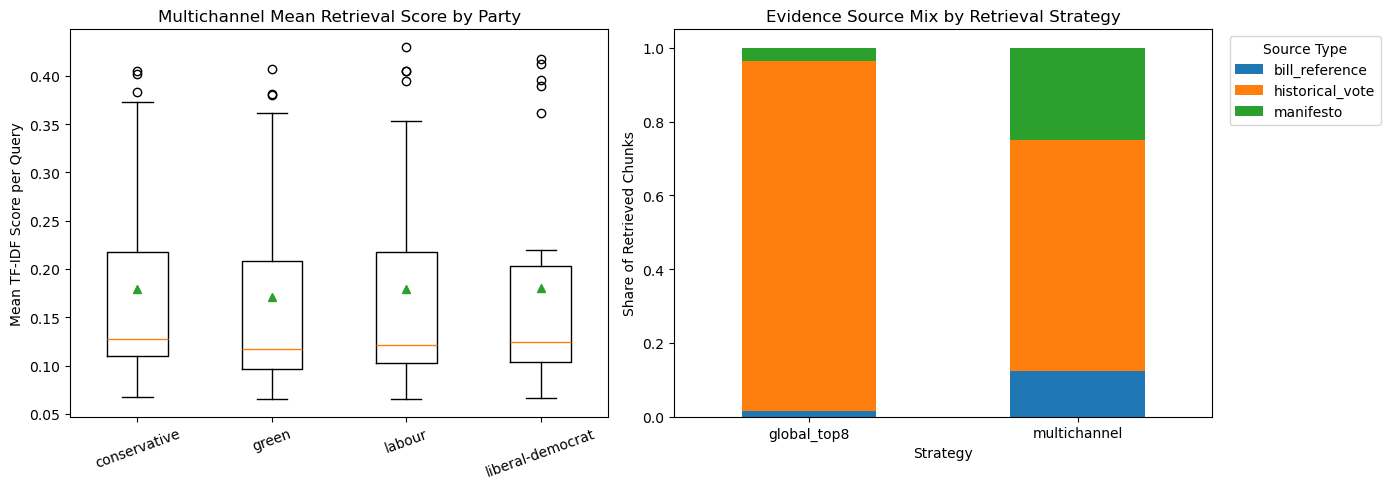

In [10]:
# 图表标题和坐标轴使用英文，代码注释保持中文。
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

party_order = PARTIES
box_data = [
    party_query_metrics.loc[
        party_query_metrics['query_party'].eq(party), 'mean_score'
    ].to_numpy()
    for party in party_order
]
axes[0].boxplot(box_data, labels=party_order, showmeans=True)
axes[0].set_title('Multichannel Mean Retrieval Score by Party')
axes[0].set_ylabel('Mean TF-IDF Score per Query')
axes[0].tick_params(axis='x', rotation=20)

mix_plot = (
    audit_evidence
    .groupby(['strategy', 'source_type'])
    .size()
    .unstack(fill_value=0)
)
mix_plot = mix_plot.div(mix_plot.sum(axis=1), axis=0)
mix_plot.plot(kind='bar', stacked=True, ax=axes[1])
axes[1].set_title('Evidence Source Mix by Retrieval Strategy')
axes[1].set_xlabel('Strategy')
axes[1].set_ylabel('Share of Retrieved Chunks')
axes[1].legend(title='Source Type', bbox_to_anchor=(1.02, 1))
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 11. Build a compact manual-review queue

自动相似度不能判断政治方向。复核队列选择 Green 分数最低的 6 个查询，以及其他三个政党各自最低的 2 个查询。每个查询保留全部八条 evidence，供后续人工判断 `relevant / partial / irrelevant` 和 `supporting / opposing / background / unclear`。

你不需要逐条阅读。运行后把 Summary 发给我，我会直接读取生成的队列进行复核。

In [11]:
# 选择最需要检查的低分 query，而不是只展示最好结果。
review_query_ids = []
for party in PARTIES:
    query_count = 6 if party == 'green' else 2
    selected_queries = (
        party_query_metrics[
            party_query_metrics['query_party'].eq(party)
        ]
        .nsmallest(query_count, 'mean_score')
        ['query_division_key']
        .tolist()
    )
    review_query_ids.extend([
        f'{division_key}__{party}__multichannel'
        for division_key in selected_queries
    ])

manual_review_queue = audit_evidence[
    audit_evidence['query_id'].isin(review_query_ids)
].copy()
manual_review_queue['query_text_excerpt'] = (
    manual_review_queue['query_title'].fillna('').astype(str).str.slice(0, 240)
)
manual_review_queue['evidence_text_excerpt'] = (
    manual_review_queue['evidence_text'].fillna('').astype(str).str.slice(0, 700)
)
manual_review_queue['manual_relevance'] = ''
manual_review_queue['manual_evidence_role'] = ''
manual_review_queue['manual_notes'] = ''

manual_review_columns = [
    'query_id', 'query_division_key', 'query_party', 'query_date',
    'query_title', 'query_policy_domain', 'query_motion_family',
    'rank', 'source_type', 'evidence_channel', 'sparse_score',
    'evidence_title', 'source_date', 'source_url', 'stance_label',
    'evidence_policy_domain', 'evidence_motion_family',
    'query_text_excerpt', 'evidence_text_excerpt',
    'manual_relevance', 'manual_evidence_role', 'manual_notes',
]
manual_review_queue = manual_review_queue[manual_review_columns]
manual_review_queue.to_csv(
    OUTPUT_DIR / 'manual_relevance_review_queue.csv',
    index=False,
)

query_strategy_scores.to_csv(
    OUTPUT_DIR / 'query_strategy_metrics.csv',
    index=False,
)
score_by_source.to_csv(
    OUTPUT_DIR / 'score_by_party_source.csv',
    index=False,
)

print('Manual-review queries:', len(review_query_ids))
print('Manual-review evidence rows:', len(manual_review_queue))
display(manual_review_queue.head(16))

Manual-review queries: 12
Manual-review evidence rows: 96


,query_id,query_division_key,query_party,query_date,query_title,query_policy_domain,query_motion_family,rank,source_type,evidence_channel,sparse_score,evidence_title,source_date,source_url,stance_label,evidence_policy_domain,evidence_motion_family,query_text_excerpt,evidence_text_excerpt,manual_relevance,manual_evidence_role,manual_notes
336,pw-2024-09-03-7-commons__green__multichannel,pw-2024-09-03-7-commons,green,2024-09-03,Clause 2 - Future provision of services,transport_infrastructure,amendment_or_clause,1,manifesto,policy,0.059388,Green Party 2024 General Election Manifesto,2024-06-12 00:00:00.000000000,https://greenparty.org.uk/app/uploads/2024/06/Green-Party-2024-General-Election-Manifesto-Long-version-with-cover.pdf,NaN,NaN,NaN,Clause 2 - Future provision of services,"y £20bn a year and is associated increase these in urban areas, and in rural areas\ngetting to school. student, restoring maintenance grants and with over 40,000 deaths a year....",,,
337,pw-2024-09-03-7-commons__green__multichannel,pw-2024-09-03-7-commons,green,2024-09-03,Clause 2 - Future provision of services,transport_infrastructure,amendment_or_clause,2,manifesto,policy,0.050982,Green Party 2024 General Election Manifesto,2024-06-12 00:00:00.000000000,https://greenparty.org.uk/app/uploads/2024/06/Green-Party-2024-General-Election-Manifesto-Long-version-with-cover.pdf,NaN,NaN,NaN,Clause 2 - Future provision of services,"ock, and the\nthat are right for them. Local authorities need to insufficient insulation. New builds and home\nFinancing our Fairer, Greener Homes Guarantee sites suitable for ...",,,
338,pw-2024-09-03-7-commons__green__multichannel,pw-2024-09-03-7-commons,green,2024-09-03,Clause 2 - Future provision of services,transport_infrastructure,amendment_or_clause,3,historical_vote,historical,0.168941,Clause 3 - Exceptions,2023-10-25 00:00:00.000000000,NaN,oppose,economy_finance_business,amendment_or_clause,Clause 2 - Future provision of services,"Historical parliamentary vote.\nParty: green.\nObserved stance: oppose.\nMotion title: Clause 3 - Exceptions.\nMotion text: Amendment proposed: 14, page 2, line 17, leave out s...",,,
339,pw-2024-09-03-7-commons__green__multichannel,pw-2024-09-03-7-commons,green,2024-09-03,Clause 2 - Future provision of services,transport_infrastructure,amendment_or_clause,4,historical_vote,historical,0.122829,Clause 4 - Changes to mission progress methodology and metrics or target dates,2022-11-23 00:00:00.000000000,NaN,oppose,other_or_unclear,amendment_or_clause,Clause 2 - Future provision of services,Historical parliamentary vote.\nParty: green.\nObserved stance: oppose.\nMotion title: Clause 4 - Changes to mission progress methodology and metrics or target dates.\nMotion t...,,,
340,pw-2024-09-03-7-commons__green__multichannel,pw-2024-09-03-7-commons,green,2024-09-03,Clause 2 - Future provision of services,transport_infrastructure,amendment_or_clause,5,historical_vote,historical,0.109705,Clause 1 - Duty on goods removed to Northern Ireland,2020-12-09 00:00:00.000000000,NaN,oppose,economy_finance_business,amendment_or_clause,Clause 2 - Future provision of services,Historical parliamentary vote.\nParty: green.\nObserved stance: oppose.\nMotion title: Clause 1 - Duty on goods removed to Northern Ireland.\nMotion text: Amendment proposed: 1...,,,
341,pw-2024-09-03-7-commons__green__multichannel,pw-2024-09-03-7-commons,green,2024-09-03,Clause 2 - Future provision of services,transport_infrastructure,amendment_or_clause,6,historical_vote,historical,0.104159,Clause 3 - Exceptions,2023-10-25 00:00:00.000000000,NaN,oppose,economy_finance_business,amendment_or_clause,Clause 2 - Future provision of services,"Historical parliamentary vote.\nParty: green.\nObserved stance: oppose.\nMotion title: Clause 3 - Exceptions.\nMotion text: Amendment proposed: 7, in clause 3, page 3, line 7, ...",,,
342,pw-2024-09-03-7-commons__green__multichannel,pw-2024-09-03-7-commons,green,2024-09-03,Clause 2 - Future provision of services,transp

## 12. Summary for review

这里不设置“Green 自动删除”门槛。检索分数只能发现异常，不能证明政党不值得研究。最终决定要结合人工相关性复核和之后的小规模 Agent 评测。

In [12]:
multichannel_source_counts = (
    multichannel
    .groupby(['query_id', 'source_type'])
    .size()
    .unstack(fill_value=0)
)

bill_multichannel = multichannel[
    multichannel['source_type'].eq('bill_reference')
]
manifesto_multichannel = multichannel[
    multichannel['source_type'].eq('manifesto')
]

bill_zero_rate = float(
    bill_multichannel['sparse_score'].le(ZERO_SCORE_TOLERANCE).mean()
)
manifesto_zero_rate = float(
    manifesto_multichannel['sparse_score'].le(ZERO_SCORE_TOLERANCE).mean()
)
mean_quota_score_delta = float(
    strategy_pivot['multichannel_minus_global'].mean()
)

if bill_zero_rate >= 0.50:
    bill_quota_note = 'review_or_remove_fixed_bill_quota'
else:
    bill_quota_note = 'fixed_bill_quota_not_obviously_zero_relevance'

if manifesto_zero_rate >= 0.25:
    manifesto_note = 'review_manifesto_retrieval_or_compare_dense'
else:
    manifesto_note = 'manifesto_sparse_retrieval_not_obviously_zero_relevance'

green_status = 'retain_pending_manual_relevance_review'

summary_lines = [
    '=== RAG RETRIEVAL AUDIT SUMMARY FOR REVIEW ===',
    f'Notebook version: {AUDIT_VERSION}',
    'API calls: 0',
    'LLM calls: 0',
    f'Dense comparison run: False',
    f'Dense library available: {DENSE_LIBRARY_AVAILABLE}',
    f'Audit divisions: {len(audit_divisions)}',
    f'Audit party queries: {len(audit_divisions) * len(PARTIES)}',
    (
        'Audit query dates: '
        f'{audit_divisions["motion_date"].min().date()} to '
        f'{audit_divisions["motion_date"].max().date()}'
    ),
    f'Audit policy domains: {audit_divisions["policy_domain_primary"].nunique()}',
    f'Audit motion families: {audit_divisions["motion_family"].nunique()}',
    f'Structural gates: {structural_gates}',
    f'Mean multichannel minus global score: {mean_quota_score_delta:.4f}',
    f'Multichannel bill zero-score rate: {bill_zero_rate:.3f}',
    f'Multichannel manifesto zero-score rate: {manifesto_zero_rate:.3f}',
    f'Bill quota diagnostic: {bill_quota_note}',
    f'Manifesto diagnostic: {manifesto_note}',
    f'Green preliminary status: {green_status}',
    f'Manual-review queries: {len(review_query_ids)}',
    f'Manual-review evidence rows: {len(manual_review_queue)}',
    'Multichannel source counts per query:',
    multichannel_source_counts.describe().round(3).to_string(),
    'Score by party and source:',
    score_by_source[
        score_by_source['strategy'].eq('multichannel')
    ].round(4).to_string(index=False),
    'Historical match diagnostics:',
    historical_match_summary.loc['multichannel'].round(3).to_string(),
    'Green paired comparison:',
    green_comparison.round(4).to_string(index=False),
    'Output directory:',
    str(OUTPUT_DIR),
    '=== END RAG RETRIEVAL AUDIT SUMMARY ===',
]

summary_text = '\n'.join(summary_lines)
print(summary_text)

with open(
    OUTPUT_DIR / 'rag_retrieval_audit_summary.txt',
    'w',
    encoding='utf-8',
) as file:
    file.write(summary_text)

=== RAG RETRIEVAL AUDIT SUMMARY FOR REVIEW ===
Notebook version: 06b-rag-audit-v1
API calls: 0
LLM calls: 0
Dense comparison run: False
Dense library available: False
Audit divisions: 24
Audit party queries: 96
Audit query dates: 2024-07-23 to 2024-12-17
Audit policy domains: 12
Audit motion families: 4
Structural gates: {'all_queries_have_8_results': True, 'temporal_leakage_gate': True, 'same_division_gate': True, 'duplicate_chunk_gate': True, 'document_diversity_gate': True}
Mean multichannel minus global score: -0.0562
Multichannel bill zero-score rate: 0.000
Multichannel manifesto zero-score rate: 0.000
Bill quota diagnostic: fixed_bill_quota_not_obviously_zero_relevance
Manifesto diagnostic: manifesto_sparse_retrieval_not_obviously_zero_relevance
Green preliminary status: retain_pending_manual_relevance_review
Manual-review queries: 12
Manual-review evidence rows: 96
Multichannel source counts per query:
source_type  bill_reference  historical_vote  manifesto
count                